<a href="https://colab.research.google.com/github/eliasakalu/ICogLabs_AI_Projects/blob/main/Final_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

In [57]:
# Divide the dataset into Training, Testing and Validation sets
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

x_val, y_val = x_train[-10000:], y_train[-10000:]
x_train, y_train = x_train[:-10000], y_train[:-10000]

print(f"The dataset I used for training:   {x_train.shape}")
print(f"The dataset I used for testing:    {x_test.shape}")
print(f"The dataset I used for validation: {x_val.shape}")

The dataset I used for training:   (50000, 28, 28)
The dataset I used for testing:    (10000, 28, 28)
The dataset I used for validation: (10000, 28, 28)


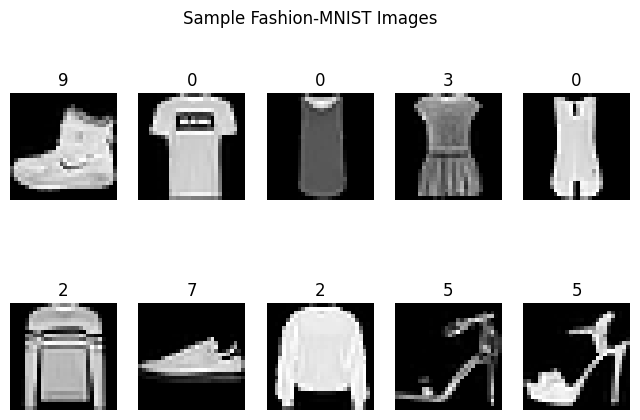

In [58]:
plt.figure(figsize=(8,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")
plt.suptitle("Sample Fashion-MNIST Images")
plt.show()

In [59]:
# Normalize the values since the pixel value is from 0-255 we need to be from 0-1
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0
x_val   = x_val.astype("float32") / 255.0

#Get the pixel size of the image
pixel = x_train.shape[1]

# Flatten the array for fully connected neural network
x_train_flatten = np.reshape(x_train,(-1,pixel**2))
x_test_flatten  = np.reshape(x_test,(-1,pixel**2))
x_val_flatten   = np.reshape(x_val,(-1,pixel**2))

# CNN Data Preparation
x_train_cnn = np.reshape(x_train, (-1, pixel, pixel, 1))
x_test_cnn  = np.reshape(x_test,  (-1, pixel, pixel, 1))
x_val_cnn   = np.reshape(x_val,   (-1, pixel, pixel, 1))

print("FC train shape :", x_train_flatten.shape)
print("CNN train shape:", x_train_cnn.shape)

FC train shape : (50000, 784)
CNN train shape: (50000, 28, 28, 1)


In [60]:
autoencoder = models.Sequential([
    layers.Input(shape=(784,)),

    # Encoder
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(32, activation="linear"),

    # Decoder
    layers.Dense(128, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(784, activation="sigmoid")
])

autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_fc = autoencoder.fit(
    x_train_flatten, x_train_flatten,
    epochs=10,
    batch_size=64,
    validation_data=(x_val_flatten, x_val_flatten),
    verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.0132 - loss: 0.3222 - val_accuracy: 0.0144 - val_loss: 0.2966
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0182 - loss: 0.2894 - val_accuracy: 0.0172 - val_loss: 0.2870
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0228 - loss: 0.2828 - val_accuracy: 0.0184 - val_loss: 0.2832
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0268 - loss: 0.2791 - val_accuracy: 0.0284 - val_loss: 0.2805
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0297 - loss: 0.2768 - val_accuracy: 0.0319 - val_loss: 0.2775
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0337 - loss: 0.2750 - val_accuracy: 0.0323 - val_loss: 0.2764
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0349 - loss: 0.2736 - val_accuracy: 0.0396 - val_loss: 0.2749
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0370 - loss: 0.2725 - val_accuracy: 0.

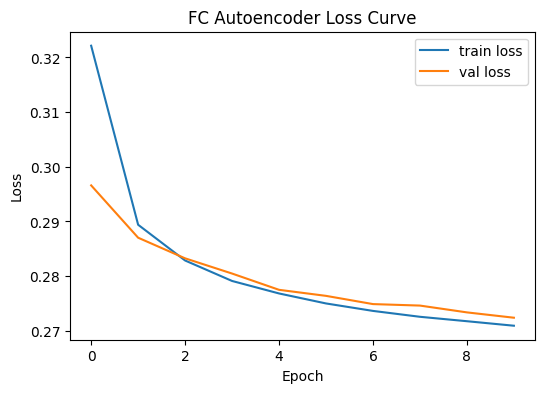

In [61]:
plt.figure(figsize=(6,4))
plt.plot(history_fc.history["loss"], label="train loss")
plt.plot(history_fc.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("FC Autoencoder Loss Curve")
plt.legend()
plt.show()

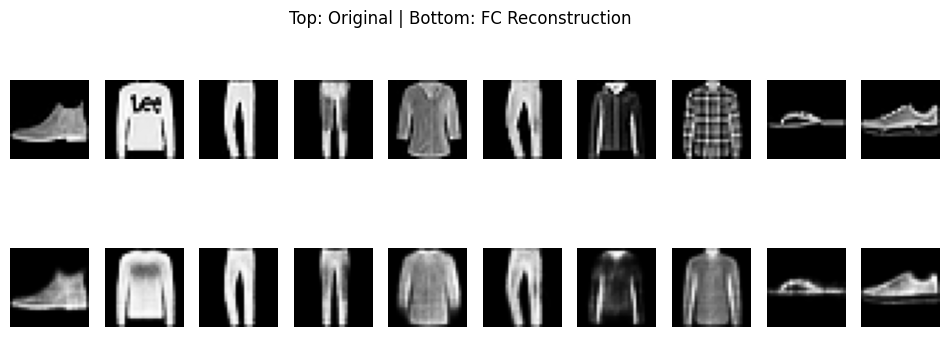

In [62]:
fc_recon = autoencoder.predict(x_test_flatten[:10], verbose=0)

plt.figure(figsize=(12,4))
for i in range(10):
    plt.subplot(2,10,i+1)
    plt.imshow(x_test_flatten[i].reshape(28,28), cmap="gray")
    plt.axis("off")

    plt.subplot(2,10,i+11)
    plt.imshow(fc_recon[i].reshape(28,28), cmap="gray")
    plt.axis("off")

plt.suptitle("Top: Original | Bottom: FC Reconstruction")
plt.show()

In [63]:
cnn_autoencoder = models.Sequential([
    layers.Input(shape=(28,28,1)),

    # Encoder
    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2), padding="same"),

    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2), padding="same"),

    # Bottleneck
    layers.Conv2D(128, (3,3), activation="relu", padding="same"),

    # Decoder
    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.UpSampling2D((2,2)),

    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.UpSampling2D((2,2)),

    layers.Conv2D(1, (3,3), activation="sigmoid", padding="same")
])

cnn_autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_cnn = cnn_autoencoder.fit(
    x_train_cnn, x_train_cnn,
    epochs=10,
    batch_size=64,
    validation_data=(x_val_cnn, x_val_cnn),
    verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.5078 - loss: 0.2822 - val_accuracy: 0.5070 - val_loss: 0.2654
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5100 - loss: 0.2609 - val_accuracy: 0.5074 - val_loss: 0.2591
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5103 - loss: 0.2565 - val_accuracy: 0.5075 - val_loss: 0.2564
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5104 - loss: 0.2542 - val_accuracy: 0.5076 - val_loss: 0.2546
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5104 - loss: 0.2528 - val_accuracy: 0.5076 - val_loss: 0.2535
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5105 - loss: 0.2517 - val_accuracy: 0.5077 - val_loss: 0.2538
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5105 - loss: 0.2510 - val_accuracy: 0.5077 - val_loss: 0.2519
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5105 - loss: 0.2504 - val_accuracy: 0

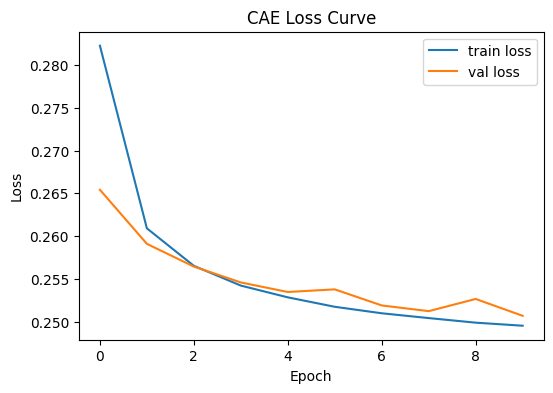

In [64]:
plt.figure(figsize=(6,4))
plt.plot(history_cnn.history["loss"], label="train loss")
plt.plot(history_cnn.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CAE Loss Curve")
plt.legend()
plt.show()

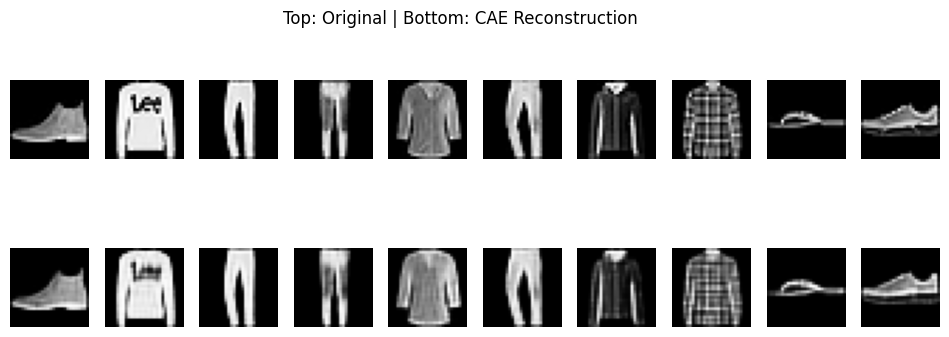

In [65]:
cnn_recon = cnn_autoencoder.predict(x_test_cnn[:10], verbose=0)

plt.figure(figsize=(12,4))
for i in range(10):
    plt.subplot(2,10,i+1)
    plt.imshow(x_test_cnn[i].reshape(28,28), cmap="gray")
    plt.axis("off")

    plt.subplot(2,10,i+11)
    plt.imshow(cnn_recon[i].reshape(28,28), cmap="gray")
    plt.axis("off")

plt.suptitle("Top: Original | Bottom: CAE Reconstruction")
plt.show()

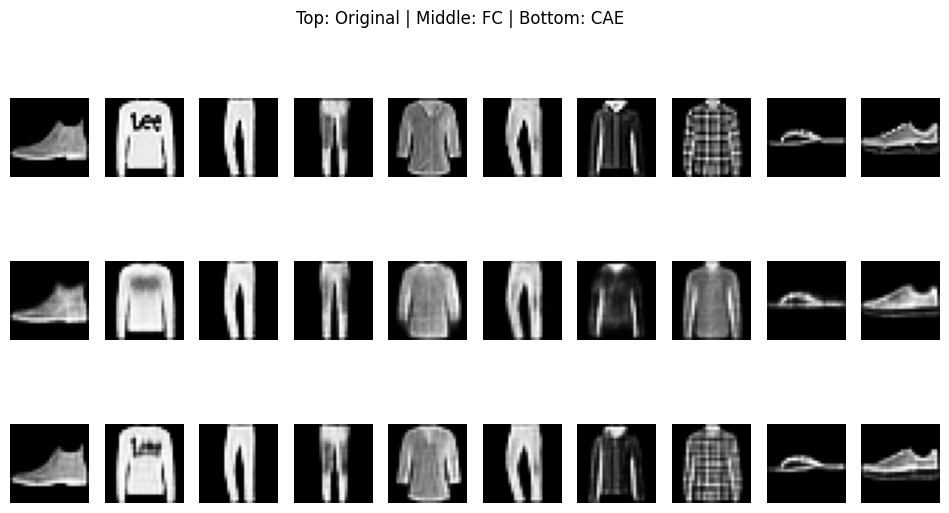

In [66]:
fc_recon = autoencoder.predict(x_test_flatten[:10], verbose=0)
cnn_recon = cnn_autoencoder.predict(x_test_cnn[:10], verbose=0)

plt.figure(figsize=(12,6))

for i in range(10):
    # Original
    plt.subplot(3,10,i+1)
    plt.imshow(x_test[i], cmap="gray")
    plt.axis("off")

    # FC
    plt.subplot(3,10,i+11)
    plt.imshow(fc_recon[i].reshape(28,28), cmap="gray")
    plt.axis("off")

    # CNN
    plt.subplot(3,10,i+21)
    plt.imshow(cnn_recon[i].reshape(28,28), cmap="gray")
    plt.axis("off")

plt.suptitle("Top: Original | Middle: FC | Bottom: CAE")
plt.show()

In [67]:
def mse_score(x_true, x_pred):
    return np.mean((x_true - x_pred) ** 2)

def psnr_score(x_true, x_pred):
    return np.mean(tf.image.psnr(x_true, x_pred, max_val=1.0).numpy())

def ssim_score(x_true, x_pred):
    return np.mean(tf.image.ssim(x_true, x_pred, max_val=1.0).numpy())

In [68]:
x_test_true = x_test.reshape(-1,28,28,1)
fc_test_pred = autoencoder.predict(x_test_flatten, verbose=0).reshape(-1,28,28,1)

fc_mse = mse_score(x_test_true, fc_test_pred)
fc_psnr = psnr_score(x_test_true, fc_test_pred)
fc_ssim = ssim_score(x_test_true, fc_test_pred)

print("FC Autoencoder Metrics")
print("MSE :", fc_mse)
print("PSNR:", fc_psnr)
print("SSIM:", fc_ssim)

FC Autoencoder Metrics
MSE : 0.009895208
PSNR: 21.021078
SSIM: 0.70780164


In [69]:
cnn_test_pred = cnn_autoencoder.predict(x_test_cnn, verbose=0)
x_test_true = x_test.reshape(-1,28,28,1)
cnn_mse = mse_score(x_test_true, cnn_test_pred)
cnn_psnr = psnr_score(x_test_true, cnn_test_pred)
cnn_ssim = ssim_score(x_test_true, cnn_test_pred)

print("CAE Metrics")
print("MSE :", cnn_mse)
print("PSNR:", cnn_psnr)
print("SSIM:", cnn_ssim)

CAE Metrics
MSE : 0.002670627
PSNR: 26.850565
SSIM: 0.9013166


## Evaluation and Comparison

Three metrics were used to evaluate reconstruction quality: MSE, PSNR, and SSIM.

- MSE measures reconstruction error; lower values indicate better performance.
- PSNR measures image quality; higher values indicate less noise.
- SSIM measures structural similarity; values closer to 1 indicate better preservation of image structure.

The results show that the Convolutional Autoencoder significantly outperforms the Fully Connected Autoencoder:

| Model | MSE ↓ | PSNR ↑ | SSIM ↑ |
|------|------|-------|-------|
| FC Autoencoder | 0.0098 | 21.02 | 0.707 |
| CAE | 0.0026 | 26.85 | 0.90 |

The CAE achieves lower reconstruction error, higher image quality, and better structural similarity.

This improvement is due to the convolutional architecture, which preserves spatial relationships and learns local features such as edges and textures. In contrast, the fully connected model flattens the image, which leads to loss of spatial information and weaker reconstruction performance.

Overall, the evaluation demonstrates that convolutional autoencoders are more effective than fully connected autoencoders for image reconstruction tasks.